In [2]:
import pandas as pd
df = pd.read_csv("../data/WELFake_Dataset.csv")
print(df.shape)

(72134, 4)


Shape: (72134, 4)

Columns:
Index(['Unnamed: 0', 'title', 'text', 'label'], dtype='str')

First 5 rows:


,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1



Missing values:
Unnamed: 0      0
title         558
text           39
label           0
dtype: int64

Shape after cleaning: (72095, 4)

Class counts:
label
1    37067
0    35028
Name: count, dtype: int64

Class proportions:
label
1    0.514141
0    0.485859
Name: proportion, dtype: float64


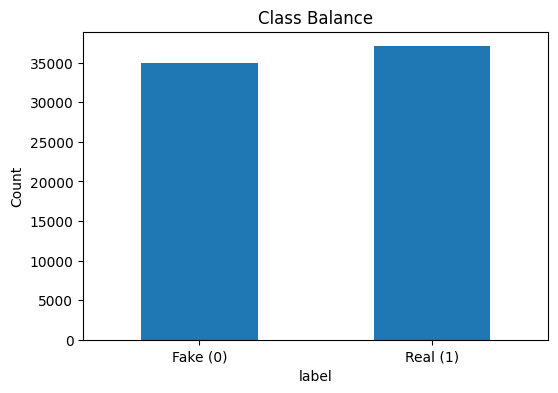

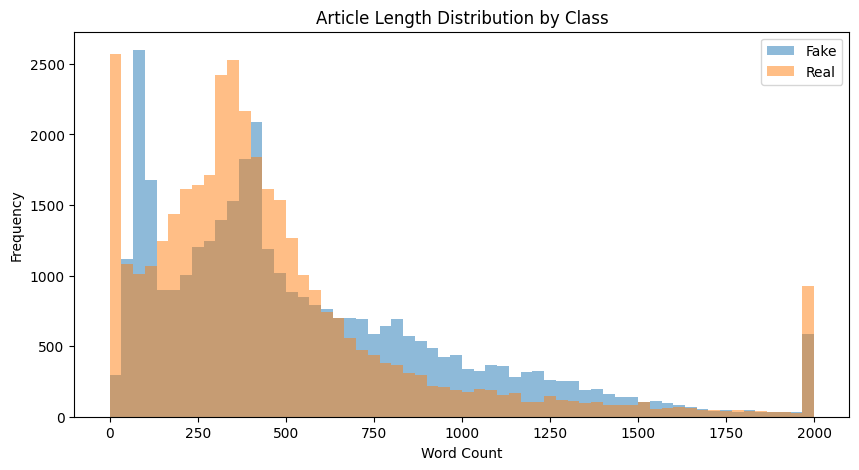


Text length summary:


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,35028.0,577.615536,563.115638,0.0,241.0,427.0,783.0,14641.0
1,37067.0,506.093938,677.279408,0.0,217.0,369.0,568.0,24234.0



Title length summary:


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,35028.0,11.046620,2.850381,2.0,9.0,11.0,13.0,30.0
1,37067.0,13.233064,5.020015,0.0,10.0,13.0,16.0,72.0


In [ ]:
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("../data/WELFake_Dataset.csv")

# Basic inspection
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)
print("\nFirst 5 rows:")
display(df.head())
print("\nSample text (first 10 rows):")
display(df["text"].head(10))

# Check missing values
print("\nMissing values:")
print(df.isnull().sum())

# Drop rows missing text or label
df = df.dropna(subset=["text", "label"]).copy()

# Fill missing titles just in case
df["title"] = df["title"].fillna("")

print("\nShape after cleaning:", df.shape)

# Class balance
print("\nClass counts:")
print(df["label"].value_counts())

print("\nClass proportions:")
print(df["label"].value_counts(normalize=True))

# Create length features
df["text_length"] = df["text"].astype(str).str.split().str.len()
df["title_length"] = df["title"].astype(str).str.split().str.len()

# Plot class balance
plt.figure(figsize=(6,4))
df["label"].value_counts().sort_index().plot(kind="bar")
plt.xticks([0, 1], ["Fake (0)", "Real (1)"], rotation=0)
plt.title("Class Balance")
plt.ylabel("Count")
plt.show()

# Plot article length distribution
plt.figure(figsize=(10,5))
for label, group in df.groupby("label"):
    plt.hist(
        group["text_length"].clip(upper=2000),
        bins=60,
        alpha=0.5,
        label="Real" if label == 1 else "Fake"
    )

plt.title("Article Length Distribution by Class")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# Summary stats
print("\nText length summary:")
display(df.groupby("label")["text_length"].describe())

print("\nTitle length summary:")
display(df.groupby("label")["title_length"].describe())